# Makers Mark comparer — vote analysis

Pairwise image preference votes from `votes.jsonl`, analyzed offline.
The notebook is safe to re-run as votes accumulate — just *Restart & Run All*.

Sections:
1. Summary
2. Pair confusion matrix
3. Size distribution
4. Position-A win rate (± 1σ)
5. Ranking — all sizes (Bradley–Terry)
6. Rankings per size

In [1]:
# Deps: numpy, pandas, matplotlib, jupyter. The rest of the project is stdlib-only;
# this notebook is the first thing in the repo to pull in the scientific stack.
import json
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
SAMPLES_DIR = ROOT / "Samples"
VOTES_PATH = ROOT / "votes.jsonl"
SIZES_PX = [20, 30, 40, 50, 60, 70, 80]

def _num(name):
    return int(name.split(".")[0])

IMAGES = sorted(
    [p.name for p in SAMPLES_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".png"],
    key=_num,
)
IMG_IDX = {name: i for i, name in enumerate(IMAGES)}
N_IMG = len(IMAGES)

rows = []
if VOTES_PATH.exists():
    with open(VOTES_PATH) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
votes = pd.DataFrame(rows, columns=["ts", "pair_id", "a", "b", "size", "winner"])
if len(votes):
    votes["size_px"] = votes["size"].str.rstrip("px").astype(int)
else:
    votes["size_px"] = pd.Series(dtype=int)

print(f"{len(votes)} votes loaded across {N_IMG} images")

502 votes loaded across 38 images


## Summary

In [2]:
total_votes = len(votes)
date_range = (votes["ts"].min(), votes["ts"].max()) if total_votes else ("—", "—")

unique_pairs = {frozenset((r.a, r.b)) for r in votes.itertuples()}
possible_pairs = comb(N_IMG, 2)

size_counts = (
    votes.groupby("size_px").size().reindex(SIZES_PX, fill_value=0)
    if total_votes else pd.Series({s: 0 for s in SIZES_PX})
)
size_counts.name = "votes"

print(f"total votes:  {total_votes}")
print(f"date range:   {date_range[0]} — {date_range[1]}")
print(f"images:       {N_IMG}")
print(f"unique pairs: {len(unique_pairs)} / {possible_pairs}")
print()
print("votes per size:")
display(size_counts.to_frame())

total votes:  502
date range:   2026-04-19T16:25:00Z — 2026-04-21T16:57:55Z
images:       38
unique pairs: 356 / 703

votes per size:


,votes
size_px,
20,68
30,71
40,69
50,79
60,64
70,79
80,72


## Pair confusion matrix

How many times each unordered pair of images appeared together, regardless
of left/right position or size. Symmetric; diagonal is zero.

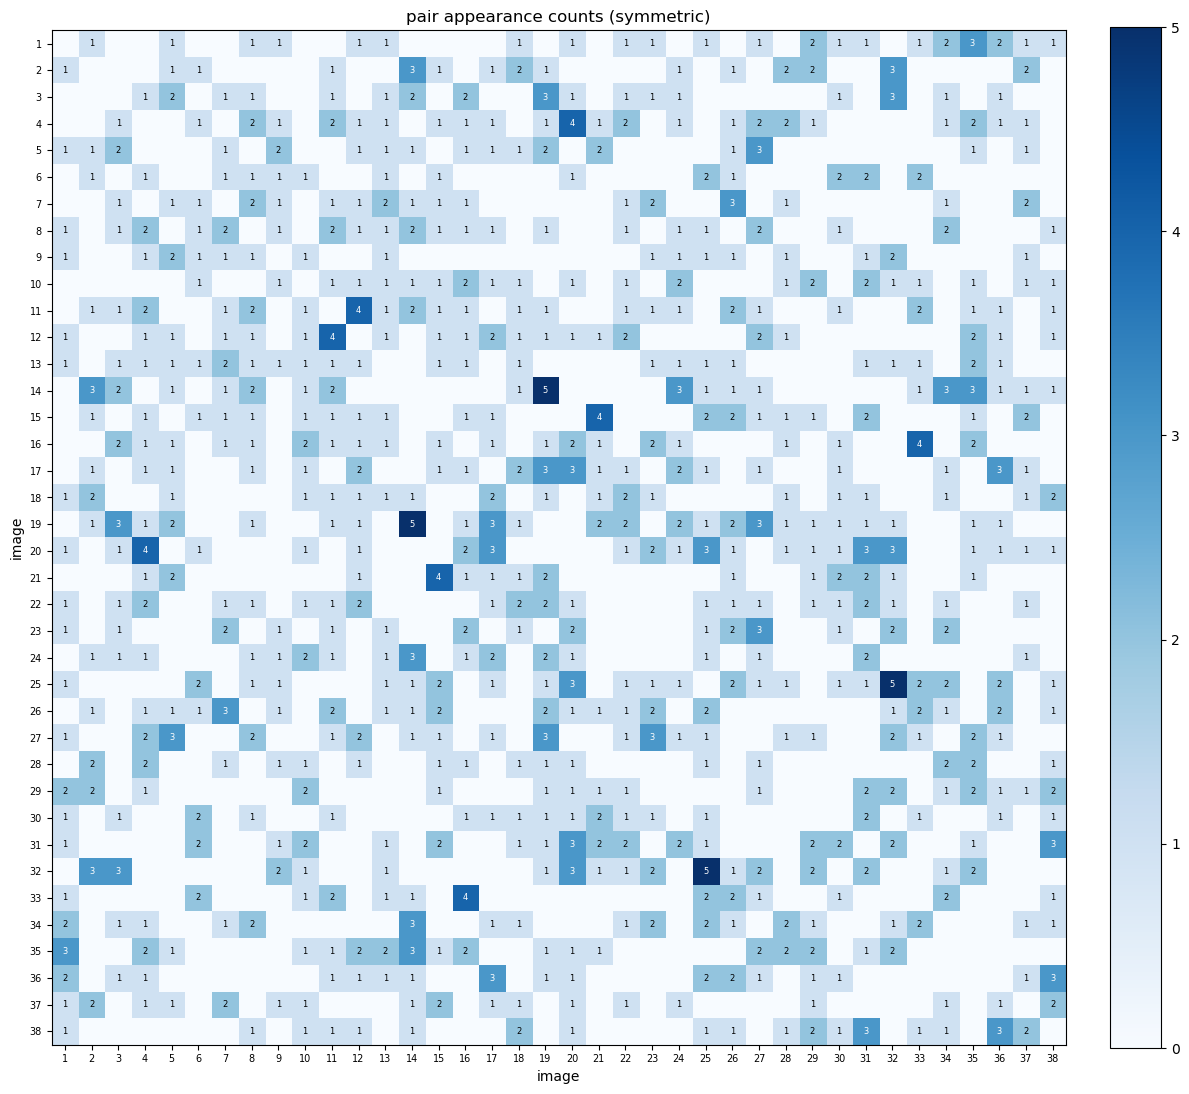

In [3]:
conf = np.zeros((N_IMG, N_IMG), dtype=int)
for r in votes.itertuples():
    i, j = IMG_IDX[r.a], IMG_IDX[r.b]
    conf[i, j] += 1
    conf[j, i] += 1

labels = [_num(n) for n in IMAGES]
fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks(range(N_IMG))
ax.set_yticks(range(N_IMG))
ax.set_xticklabels(labels, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("image")
ax.set_ylabel("image")
ax.set_title("pair appearance counts (symmetric)")
vmax = conf.max() if conf.size else 0
for i in range(N_IMG):
    for j in range(N_IMG):
        v = conf[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=6,
                    color="white" if v > vmax / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Size distribution

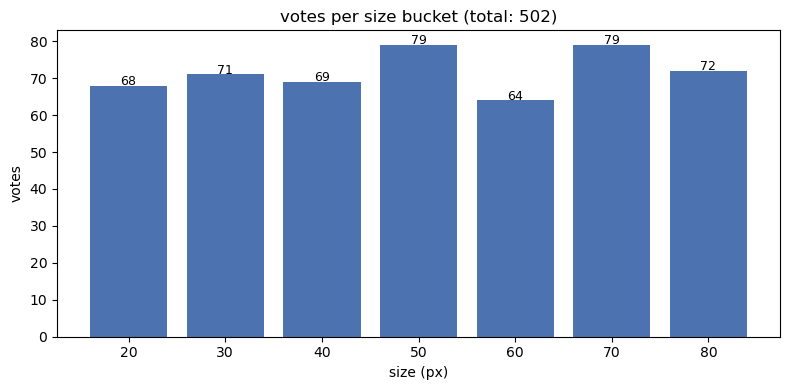

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(s) for s in SIZES_PX], [size_counts[s] for s in SIZES_PX], color="#4c72b0")
ax.set_xlabel("size (px)")
ax.set_ylabel("votes")
ax.set_title(f"votes per size bucket (total: {total_votes})")
for i, s in enumerate(SIZES_PX):
    v = int(size_counts[s])
    if v:
        ax.text(i, v + 0.2, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Position (A) win rate

Did the image shown on the *left* (position A) win more often than chance?
Error bars are ±1σ binomial standard error $\sqrt{p(1-p)/n}$. A reference
line at 0.5 marks no position bias.

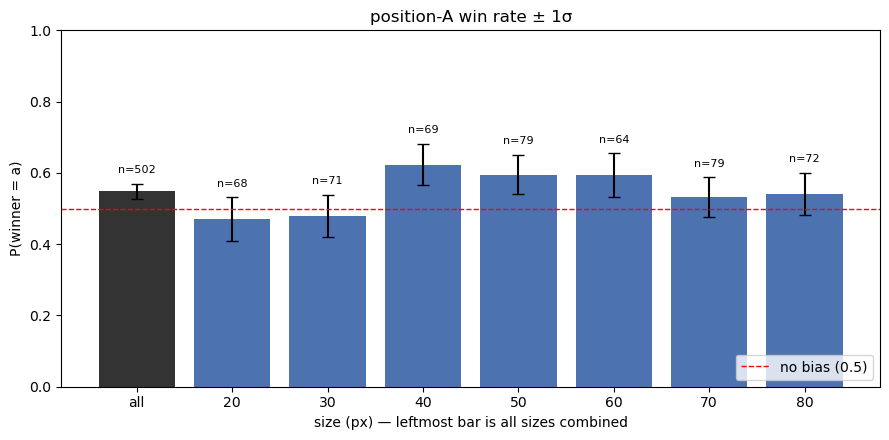

In [5]:
def a_rate(df):
    n = len(df)
    if n == 0:
        return None
    wins_a = int((df["winner"] == "a").sum())
    p = wins_a / n
    se = np.sqrt(p * (1 - p) / n)
    return p, se, n

buckets = [("all", votes)] + [(f"{s}", votes[votes["size_px"] == s]) for s in SIZES_PX]
labels, ps, ses, ns = [], [], [], []
for name, df in buckets:
    res = a_rate(df)
    if res is None:
        continue
    p, se, n = res
    labels.append(name)
    ps.append(p)
    ses.append(se)
    ns.append(n)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(labels))
colors = ["#333"] + ["#4c72b0"] * (len(labels) - 1)
ax.bar(x, ps, yerr=ses, capsize=4, color=colors)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="no bias (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("P(winner = a)")
ax.set_xlabel("size (px) — leftmost bar is all sizes combined")
ax.set_ylim(0, 1)
ax.set_title("position-A win rate ± 1σ")
for i, (p, n) in enumerate(zip(ps, ns)):
    ax.text(i, min(p + ses[i] + 0.03, 0.97), f"n={n}", ha="center", fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Ranking — all sizes combined

Bradley–Terry MLE fit by the standard minorization–maximization update

$$\pi_i \leftarrow \frac{W_i}{\sum_{j \ne i} N_{ij} / (\pi_i + \pi_j)}$$

Log-scores are centered at zero (so `bt_score = 0` ≈ average).
Images that have never lost or never won are separated into an
*extremes* table since their BT score diverges.

In [6]:
def tally(df, images):
    idx = {n: i for i, n in enumerate(images)}
    n = len(images)
    wins = np.zeros(n, dtype=float)
    losses = np.zeros(n, dtype=float)
    games = np.zeros((n, n), dtype=float)
    for r in df.itertuples():
        i, j = idx[r.a], idx[r.b]
        games[i, j] += 1
        games[j, i] += 1
        if r.winner == "a":
            wins[i] += 1
            losses[j] += 1
        else:
            wins[j] += 1
            losses[i] += 1
    return wins, losses, games

def fit_bradley_terry(wins, games, max_iter=500, tol=1e-8):
    n = len(wins)
    played = games.sum(axis=1) > 0
    pi = np.ones(n)
    for _ in range(max_iter):
        pi_sum = pi[:, None] + pi[None, :]
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(games > 0, games / pi_sum, 0.0)
        denom = ratio.sum(axis=1)
        pi_new = np.where(denom > 0, wins / np.maximum(denom, 1e-300), 0.0)
        pi_new[~played] = 1.0
        active = played & (pi_new > 0) & np.isfinite(pi_new)
        if active.any():
            gm = np.exp(np.log(pi_new[active]).mean())
            if gm > 0:
                pi_new = pi_new / gm
            change = np.max(np.abs(
                np.log(np.maximum(pi_new[active], 1e-300))
                - np.log(np.maximum(pi[active], 1e-300))
            ))
        else:
            change = 0.0
        pi = pi_new
        if change < tol:
            break
    log_pi = np.full(n, np.nan)
    good = played & (pi > 0) & np.isfinite(pi)
    log_pi[good] = np.log(pi[good])
    if good.any():
        log_pi[good] -= log_pi[good].mean()
    log_pi[played & (pi == 0)] = -np.inf
    # undefeated — detect by: W_i > 0 and losses_i == 0 (caller separates these)
    return log_pi

def build_ranking(df, images):
    wins, losses, games = tally(df, images)
    log_pi = fit_bradley_terry(wins, games)
    total = wins + losses
    # mark undefeated (no losses, some wins) and winless (no wins, some losses) as non-finite
    undefeated = (total > 0) & (losses == 0)
    winless = (total > 0) & (wins == 0)
    log_pi = log_pi.copy()
    log_pi[undefeated] = np.inf
    log_pi[winless] = -np.inf
    rate = np.where(total > 0, wins / np.maximum(total, 1), np.nan)
    df_out = pd.DataFrame({
        "file": images,
        "games": total.astype(int),
        "wins": wins.astype(int),
        "losses": losses.astype(int),
        "win_rate": rate,
        "bt_score": log_pi,
    })
    df_out = df_out[df_out["games"] > 0].copy()
    finite = df_out[np.isfinite(df_out["bt_score"])].sort_values(
        "bt_score", ascending=False
    ).reset_index(drop=True)
    finite.insert(0, "rank", finite.index + 1)
    extremes = df_out[~np.isfinite(df_out["bt_score"])].sort_values(
        "bt_score", ascending=False
    ).reset_index(drop=True)
    return finite, extremes

overall_ranking, overall_extremes = build_ranking(votes, IMAGES)

fmt = {"win_rate": "{:.1%}", "bt_score": "{:+.3f}"}
display(overall_ranking.style.format(fmt))
if len(overall_extremes):
    display(Markdown("**Extremes** (undefeated or winless — BT score diverges):"))
    display(overall_extremes.style.format(fmt))

,rank,file,games,wins,losses,win_rate,bt_score
0,1,30.png,21,17,4,81.0%,+1.684
1,2,17.png,29,22,7,75.9%,+1.564
2,3,12.png,28,22,6,78.6%,+1.472
3,4,28.png,20,16,4,80.0%,+1.470
4,5,25.png,35,27,8,77.1%,+1.254
5,6,21.png,21,14,7,66.7%,+0.897
6,7,5.png,23,15,8,65.2%,+0.596
7,8,8.png,27,17,10,63.0%,+0.566
8,9,20.png,35,21,14,60.0%,+0.555
9,10,34.png,26,15,11,57.7%,+0.369


## Rankings per size

One ranking per size bucket. Counts will be sparse per size (expect single
digits per image), so treat these as exploratory — BT scores here are
noisy estimates.

In [7]:
for s in SIZES_PX:
    sub = votes[votes["size_px"] == s]
    display(Markdown(f"### {s}px — {len(sub)} votes"))
    if len(sub) == 0:
        display(Markdown("*no votes at this size yet*"))
        continue
    ranking, extremes = build_ranking(sub, IMAGES)
    display(ranking.style.format(fmt))
    if len(extremes):
        display(Markdown("*extremes (undefeated / winless):*"))
        display(extremes.style.format(fmt))

### 20px — 68 votes

,rank,file,games,wins,losses,win_rate,bt_score
0,1,38.png,4,3,1,75.0%,+6.322
1,2,7.png,2,1,1,50.0%,+4.969
2,3,19.png,5,2,3,40.0%,+2.690
3,4,36.png,6,3,3,50.0%,+2.621
4,5,17.png,4,3,1,75.0%,+2.620
5,6,25.png,3,2,1,66.7%,+2.605
6,7,26.png,3,1,2,33.3%,+2.598
7,8,12.png,3,2,1,66.7%,+0.768
8,9,35.png,4,3,1,75.0%,+0.583
9,10,5.png,6,2,4,33.3%,+0.356


*extremes (undefeated / winless):*

,file,games,wins,losses,win_rate,bt_score
0,2.png,4,4,0,100.0%,+inf
1,13.png,3,3,0,100.0%,+inf
2,21.png,4,4,0,100.0%,+inf
3,24.png,5,5,0,100.0%,+inf
4,27.png,5,5,0,100.0%,+inf
5,34.png,4,4,0,100.0%,+inf
6,6.png,1,0,1,0.0%,-inf
7,8.png,5,0,5,0.0%,-inf
8,9.png,3,0,3,0.0%,-inf
9,16.png,2,0,2,0.0%,-inf


### 30px — 71 votes

...

,file,games,wins,losses,win_rate,bt_score
0,5.png,4,4,0,100.0%,+inf
1,6.png,3,3,0,100.0%,+inf
2,8.png,3,3,0,100.0%,+inf
3,23.png,4,4,0,100.0%,+inf
4,29.png,2,2,0,100.0%,+inf
5,30.png,2,2,0,100.0%,+inf
6,32.png,2,2,0,100.0%,+inf
7,2.png,2,0,2,0.0%,-inf
8,3.png,2,0,2,0.0%,-inf
9,10.png,2,0,2,0.0%,-inf


### 80px — 72 votes

,rank,file,games,wins,losses,win_rate,bt_score
0,1,32.png,2,1,1,50.0%,+7.058
1,2,38.png,2,1,1,50.0%,+6.411
2,3,28.png,3,2,1,66.7%,+2.279
3,4,18.png,2,1,1,50.0%,+2.267
4,5,25.png,5,3,2,60.0%,+2.261
5,6,17.png,8,6,2,75.0%,+2.254
6,7,12.png,6,5,1,83.3%,+1.988
7,8,31.png,4,3,1,75.0%,+1.351
8,9,8.png,4,3,1,75.0%,+1.130
9,10,27.png,4,2,2,50.0%,+0.927


*extremes (undefeated / winless):*

,file,games,wins,losses,win_rate,bt_score
0,10.png,2,2,0,100.0%,+inf
1,13.png,1,1,0,100.0%,+inf
2,15.png,1,1,0,100.0%,+inf
3,30.png,3,3,0,100.0%,+inf
4,1.png,5,0,5,0.0%,-inf
5,7.png,3,0,3,0.0%,-inf
6,36.png,3,0,3,0.0%,-inf
